In [1]:
from pathlib import Path
print(Path.cwd())

/Users/ortakhesap/Desktop/syai


In [1]:
!pip -q install scikit-learn

# Density Estimation & Clustering on Forex Log Returns

## Objective
This notebook models the probability structure of Forex log-returns using:
- **K-Means clustering**
- **Gaussian Mixture Model (GMM)**

We analyze daily log returns:
\[
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
\]
instead of raw exchange rates because returns are more suitable for distribution modeling.

## Methods
- **K-Means**: partitions the data into K clusters based on distance (non-probabilistic).
- **Gaussian Mixture Model (GMM)**: estimates the data as a mixture of Gaussian distributions:
\[
p(x)=\sum_{k=1}^{K}\pi_k \mathcal{N}(x|\mu_k,\Sigma_k)
\]
GMM parameters are estimated using the **Expectation–Maximization (EM)** algorithm.

Model selection is performed using:
- Silhouette score (K-Means)
- AIC/BIC (GMM)

## Results & Interpretation

### K-Means
K-Means identifies structural clusters in the return space (e.g., low vs high volatility regions).
It minimizes within-cluster variance but does not estimate a probability density.

### Gaussian Mixture Model (GMM)
GMM provides:
- Component means and covariances
- Posterior probabilities (soft clustering)
- Full probability density estimation

The EM algorithm iteratively:
1. Computes responsibilities (E-step)
2. Updates parameters (M-step)
until convergence.

### Interpretation
If multiple components are selected (via BIC), this suggests the return distribution is better described by multiple regimes rather than a single Gaussian.

Density contours and decision boundaries visualize:
- Regime separation
- Probability surfaces
- Model confidence

This supports the conclusion that FX returns exhibit multi-modal or regime-based behavior rather than a simple normal distribution.

Using CSV: /Users/ortakhesap/Desktop/syai/daily_forex_rates.csv
Selected pair: EUR/ZWL
Samples used: 1073


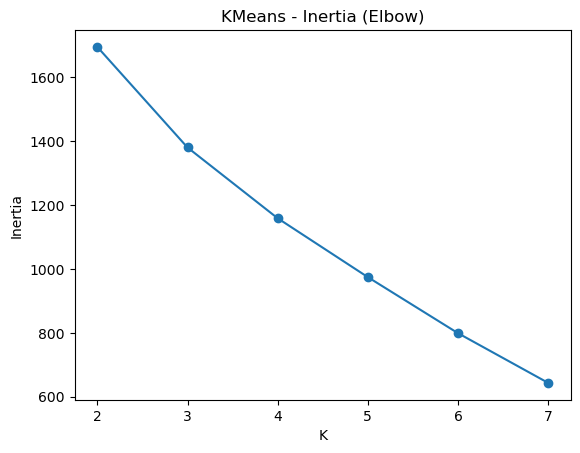

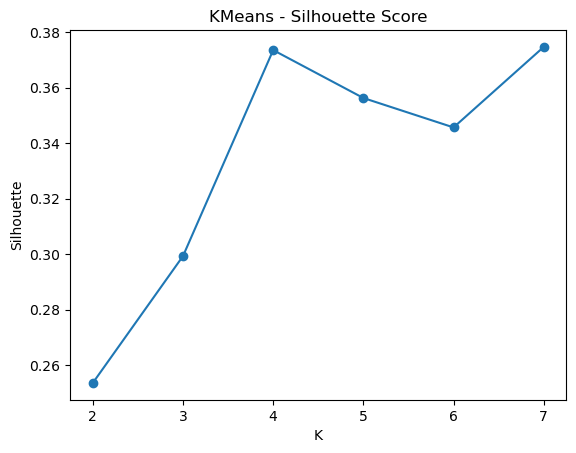

Best K (by silhouette): 7


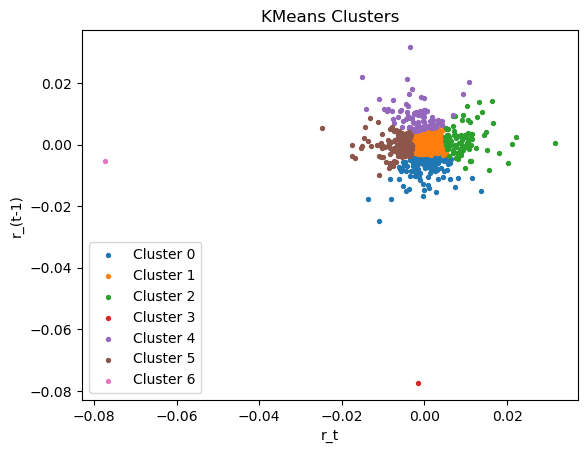

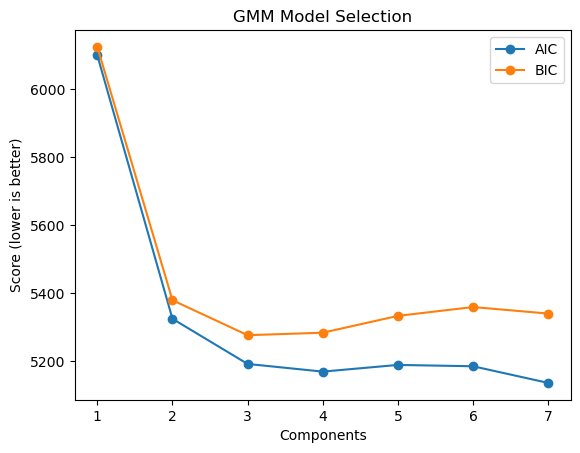

Best components (by BIC): 3
Average posterior confidence: 0.812577592156732


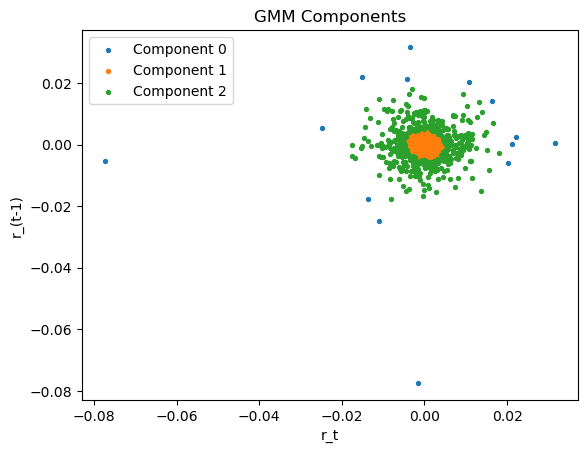

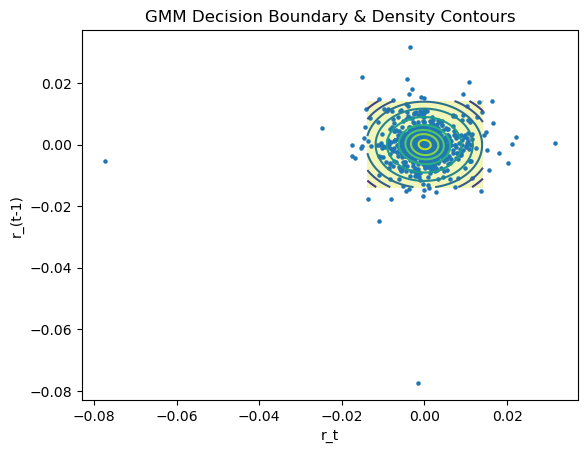


=== MODEL FIT SUMMARY ===
KMeans inertia: 643.0392537242511
KMeans silhouette: 0.3747278124736747
GMM BIC: 5276.384330834527
GMM AIC: 5191.754697209805


In [1]:
# =========================================================
# DENSITY ESTIMATION & CLUSTERING ON FOREX LOG RETURNS
# KMEANS + GAUSSIAN MIXTURE MODEL (GMM)
# =========================================================

import numpy as np #lib for numerical computing arrays logs
import pandas as pd #data loading tables
import matplotlib.pyplot as plt #plotting histogram scatters
from pathlib import Path #path handling

from sklearn.cluster import KMeans #for kMeans clustering
from sklearn.mixture import GaussianMixture #to use gaussian mixture model
from sklearn.preprocessing import StandardScaler #for z score
from sklearn.metrics import silhouette_score #clustering quality metric

# ---------------------------------------------------------
# 1) LOAD DATA (auto-detect CSV in folder/subfolders)
# ---------------------------------------------------------
#find a CSV file automatically and pick the most recently modified one.
csvs = sorted(Path.cwd().rglob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)

#safety check if list is empty stop script
if not csvs:
    raise FileNotFoundError("No CSV found in current directory or subdirectories.")


csv_path = csvs[0] #choose newest csv file, most recent file
print("Using CSV:", csv_path) #print the csv file

#load csv into pandas
df = pd.read_csv(csv_path)

#clean up collumn names erase spaces fix lowercase etc.
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

required = ["date", "base_currency", "currency", "exchange_rate"] #collumn names to work on

#loop through required collumns if one missing stops the program and gives error
for col in required:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

#Convert the date column to actual datetime object
df["date"] = pd.to_datetime(df["date"], errors="coerce")

#Force the exchange rate column to be numeric
df["exchange_rate"] = pd.to_numeric(df["exchange_rate"], errors="coerce")

# ---------------------------------------------------------
# 2) SELECT CURRENCY PAIR
# ---------------------------------------------------------

#base currency ve currency pairi olusturulur
pairs = df[["base_currency", "currency"]].drop_duplicates()


#usd eur varsa onu pairle yoksa bir sonraki ilk pair
if (pairs["base_currency"] == "USD").any() and (pairs["currency"] == "EUR").any():
    base, curr = "USD", "EUR"
else:
    base, curr = pairs.iloc[0]

fx = df[(df["base_currency"] == base) & (df["currency"] == curr)].copy() #filtered data frame for selected currency pair
fx = fx.sort_values("date") #sort data chronologically
fx = fx[fx["exchange_rate"] > 0] #exchange rate must be bigger than 0

print(f"Selected pair: {base}/{curr}")

# ---------------------------------------------------------
# 3) COMPUTE LOG RETURNS
# ---------------------------------------------------------
# Calculate the logarithmic return: ln(Price Today / Price Yesterday)
fx["r"] = np.log(fx["exchange_rate"] / fx["exchange_rate"].shift(1))
fx = fx.replace([np.inf, -np.inf], np.nan).dropna() #fix zero division errors to stop error

# Create 2D feature space  previous and today (r_t , r_{t-1}) 
fx["r_lag1"] = fx["r"].shift(1)
fx = fx.dropna()

X = fx[["r", "r_lag1"]].to_numpy() #extract todays and yesterdays returns

# Standardize features
scaler = StandardScaler() #initiliaze a scaler to normalize data
X_scaled = scaler.fit_transform(X) #fit the normal

print("Samples used:", X_scaled.shape[0]) # Print number of usable samples after cleaning

# =========================================================
# 4) K-MEANS CLUSTERING
# =========================================================

Ks = range(2, 8) # test k means between 2 and 7 

#set up evaluation metrics for tests
sil_scores = []
inertias = []

#loop through each k
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42) #setting up the kmeans model run 20 times with 20 different start point
    labels = km.fit_predict(X_scaled) #fit data and get cluster label
    sil_scores.append(silhouette_score(X_scaled, labels))# Compute silhouette score (cluster separation quality)
    inertias.append(km.inertia_) #Store inertia [SSE (called inertia in scikitlearn) if lower = tighter cluster and higher k]

# Model customisation and plotting of inertia, silhoutte 

#inertia curve
plt.figure() 
plt.plot(Ks, inertias, marker="o")
plt.title("KMeans - Inertia (Elbow)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

#silhoutte curve
plt.figure()
plt.plot(Ks, sil_scores, marker="o")
plt.title("KMeans - Silhouette Score")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()


#select the K with highest silhoutte score and print
best_k = Ks[np.argmax(sil_scores)] 
print("Best K (by silhouette):", best_k)

kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=42)  #Foster final KMeans model using best K
fx["kmeans_cluster"] = kmeans.fit_predict(X_scaled) #Assign each point a final cluster label

# Cluster visualization by plot
plt.figure()
for c in sorted(fx["kmeans_cluster"].unique()): #Loop through cluster ids present and scatterplots them
    sub = fx[fx["kmeans_cluster"] == c]
    plt.scatter(sub["r"], sub["r_lag1"], s=8, label=f"Cluster {c}")
plt.title("KMeans Clusters")
plt.xlabel("r_t")
plt.ylabel("r_(t-1)")
plt.legend()
plt.show()

# =========================================================
# 5) GAUSSIAN MIXTURE MODEL (DENSITY ESTIMATION)
# =========================================================

components_range = range(1, 8) #check between 1 and 7 compoet of gmm bell curves
aics, bics = [], [] #Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) lists initilaize


#test differet gmm shapes through loop
for c in components_range:
    gmm = GaussianMixture(n_components=c, covariance_type="full", random_state=42)#oval instead of perfect circle
    gmm.fit(X_scaled)#fit model to data
    #Record the AIC and BIC scores (lower scores mean a better, more efficient model)
    aics.append(gmm.aic(X_scaled))
    bics.append(gmm.bic(X_scaled))

#starting and  customizing plots
plt.figure()
plt.plot(components_range, aics, marker="o", label="AIC")
plt.plot(components_range, bics, marker="o", label="BIC")
plt.title("GMM Model Selection")
plt.xlabel("Components")
plt.ylabel("Score (lower is better)")
plt.legend()
plt.show()

# Choose number of components with lowest BIC ad print it
best_c = components_range[np.argmin(bics)]
print("Best components (by BIC):", best_c)

# Train final GMM using the best number of components
gmm = GaussianMixture(n_components=best_c, covariance_type="full", random_state=42)
gmm.fit(X_scaled)#fit final model

fx["gmm_cluster"] = gmm.predict(X_scaled)#Hard assignment: most likely component for each point
responsibilities = gmm.predict_proba(X_scaled)#Soft assignment: posterior probabilities per component
fx["gmm_confidence"] = responsibilities.max(axis=1)#Confidence: max posterior probability per point

print("Average posterior confidence:", fx["gmm_confidence"].mean()) #print verage certainty of assignments

# GMM cluster visualization customization
plt.figure()
for c in sorted(fx["gmm_cluster"].unique()):
    sub = fx[fx["gmm_cluster"] == c]
    plt.scatter(sub["r"], sub["r_lag1"], s=8, label=f"Component {c}")
plt.title("GMM Components")
plt.xlabel("r_t")
plt.ylabel("r_(t-1)")
plt.legend()
plt.show()

# =========================================================
# 6) DECISION BOUNDARY + DENSITY SURFACE
# =========================================================
#define a plotting window using central quantiles to avoid extreme outliers dominating the axes
x_min, x_max = fx["r"].quantile(0.01), fx["r"].quantile(0.99)
y_min, y_max = fx["r_lag1"].quantile(0.01), fx["r_lag1"].quantile(0.99)
#2d grid define
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
#stadardize 2d grid and flatten
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

log_density = gmm.score_samples(grid_scaled) # Compute log p(x) for each grid point under the GMM
Z = log_density.reshape(xx.shape)# Reshape back to 2D surface for contour plotting


decision = gmm.predict(grid_scaled).reshape(xx.shape) # Component label for each grid point

#New plot
plt.figure()
plt.contourf(xx, yy, decision, alpha=0.3)
plt.contour(xx, yy, Z, levels=10)
plt.scatter(fx["r"], fx["r_lag1"], s=5)
plt.title("GMM Decision Boundary & Density Contours")
plt.xlabel("r_t")
plt.ylabel("r_(t-1)")
plt.show()

#Full model result summary
print("\n=== MODEL FIT SUMMARY ===")
print("KMeans inertia:", kmeans.inertia_)
print("KMeans silhouette:", silhouette_score(X_scaled, fx["kmeans_cluster"]))
print("GMM BIC:", gmm.bic(X_scaled))
print("GMM AIC:", gmm.aic(X_scaled))